In [1]:
!pip -q install datasets timm torchmetrics

import os
import math
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import IterableDataset, DataLoader

from torchvision import transforms, models
from datasets import load_dataset
from tqdm import tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 23.7 MB/s eta 0:00:00


In [2]:
from datasets import load_dataset

ds_stream = load_dataset("Manas2703/chest-xray-14", split="train", streaming=True)

ex = next(iter(ds_stream))
print("Keys:", ex.keys())
for k in ex.keys():
    v = ex[k]
    print(k, type(v), str(v)[:120])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Keys: dict_keys(['_data_files', '_fingerprint', '_format_columns', '_format_kwargs', '_format_type', '_output_all_columns', '_split'])
_data_files <class 'list'> [{'filename': 'data-00000-of-00001.arrow'}]
_fingerprint <class 'str'> e005b21b60107bcb
_format_columns <class 'NoneType'> None
_format_kwargs <class 'dict'> {}
_format_type <class 'NoneType'> None
_output_all_columns <class 'bool'> False
_split <class 'NoneType'> None


In [3]:
from datasets import load_dataset

# Try loading with explicit split
ds_stream = load_dataset("Manas2703/chest-xray-14", split="train", streaming=True)

it = iter(ds_stream)
ex = next(it)

print("Example type:", type(ex))
print("Example keys:", ex.keys())
for k, v in ex.items():
    print(k, type(v), str(v)[:120])

Example type: <class 'dict'>
Example keys: dict_keys(['_data_files', '_fingerprint', '_format_columns', '_format_kwargs', '_format_type', '_output_all_columns', '_split'])
_data_files <class 'list'> [{'filename': 'data-00000-of-00001.arrow'}]
_fingerprint <class 'str'> e005b21b60107bcb
_format_columns <class 'NoneType'> None
_format_kwargs <class 'dict'> {}
_format_type <class 'NoneType'> None
_output_all_columns <class 'bool'> False
_split <class 'NoneType'> None


In [5]:
!pip -q install pandas

import os, re, tarfile, glob
import pandas as pd

os.makedirs("nih", exist_ok=True)

# 1) Download the NIH metadata CSV (small)
!wget -q -O nih/Data_Entry_2017_v2020.csv "https://nihcc.app.box.com/v/ChestXray-NIHCC/file/220660789610"

# 2) Download ONLY the first image shard (about a few GB)
# (NIH provides 12 shards; we start with 001)
!wget -q -O nih/images_001.tar.gz "https://nihcc.app.box.com/shared/static/vfk49d74nhbxq3nqjg0900w5nvkorp5c.gz"

print("Downloaded metadata + images_001.tar.gz")
print("Tar size (GB):", os.path.getsize("nih/images_001.tar.gz")/1e9)

Downloaded metadata + images_001.tar.gz
Tar size (GB): 2.008470987


In [14]:
!mkdir -p nih

# Download NIH metadata CSV from GitHub raw (reliable)
!wget -O nih/Data_Entry_2017.csv \
https://raw.githubusercontent.com/gregwchase/nih-chest-xray/master/data/Data_Entry_2017.csv

# Verify it's not empty and looks like CSV
!ls -lh nih/Data_Entry_2017.csv
!head -n 3 nih/Data_Entry_2017.csv

--2026-03-04 08:08:47--  https://raw.githubusercontent.com/gregwchase/nih-chest-xray/master/data/Data_Entry_2017.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8659561 (8.3M) [text/plain]
Saving to: ‘nih/Data_Entry_2017.csv’

nih/Data_Entry_2017 100%[===================>]   8.26M  --.-KB/s    in 0.1s    

2026-03-04 08:08:50 (78.7 MB/s) - ‘nih/Data_Entry_2017.csv’ saved [8659561/8659561]

-rw-r--r-- 1 root root 8.3M Mar  4 08:08 nih/Data_Entry_2017.csv
Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],
00000001_000.png,Cardiomegaly,000,00000001,058Y,M,PA,2682,2749,0.143,0.143
00000001_001.png,Cardiomegaly|Emphysema,001,00000001,058Y,M,PA,2894,2729,0.143,0

In [15]:
import pandas as pd

CSV_PATH = "nih/Data_Entry_2017.csv"
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
print(df.columns)
df.head()

Shape: (112120, 12)
Index(['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID',
       'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width',
       'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11'],
      dtype='object')


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,058Y,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,058Y,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,058Y,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,081Y,F,PA,2582,2991,0.143,0.143,NaN


In [18]:
!ls -lh nih/images_001.tar.gz
!gzip -dkf nih/images_001.tar.gz   # creates nih/images_001.tar
!ls -lh nih/images_001.tar

-rw-r--r-- 1 root root 1.9G Mar  4 07:23 nih/images_001.tar.gz
-rw-r--r-- 1 root root 1.9G Mar  4 07:23 nih/images_001.tar


In [20]:
# ----------------------------
CSV_PATH = "nih/Data_Entry_2017.csv"
TAR_GZ_PATH = "nih/images_001.tar.gz"
TAR_PATH = "nih/images_001.tar"

In [21]:
# ----------------------------
# 2) Load metadata and prepare labels
# ----------------------------
df = pd.read_csv(CSV_PATH)

LABELS = [
    "Atelectasis","Cardiomegaly","Consolidation","Edema","Effusion","Emphysema",
    "Fibrosis","Hernia","Infiltration","Mass","No Finding","Nodule",
    "Pleural_Thickening","Pneumonia","Pneumothorax"
]

df["Finding Labels"] = df["Finding Labels"].astype(str).str.split("|")
for lab in LABELS:
    key = lab.replace("_", " ")
    df[lab] = df["Finding Labels"].apply(lambda labs: int(key in labs))

# ----------------------------
# 3) Filter metadata to images present in the TAR
# ----------------------------
with tarfile.open(TAR_PATH, "r:") as tar:
    tar_names = set(os.path.basename(m.name) for m in tar.getmembers() if m.isfile())

df = df[df["Image Index"].isin(tar_names)].reset_index(drop=True)
print("Usable rows from TAR:", len(df))

# ----------------------------
# 4) Train/Val split
# ----------------------------
train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)

# ----------------------------
# 5) Dataset that reads images from .tar (fast compared to .tar.gz)
# ----------------------------
tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class NIHTarDataset(Dataset):
    def __init__(self, dataframe, tar_path, labels, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.labels = labels
        self.transform = transform

        # Important: keep tar open; use num_workers=0 in DataLoader
        self.tar = tarfile.open(tar_path, "r:")
        self.name_map = {os.path.basename(m.name): m.name for m in self.tar.getmembers() if m.isfile()}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, "Image Index"]
        member_name = self.name_map[img_name]
        f = self.tar.extractfile(member_name)
        img = Image.open(io.BytesIO(f.read())).convert("RGB")

        if self.transform:
            img = self.transform(img)

        y = torch.tensor(self.df.loc[idx, self.labels].values.astype(np.float32))
        return img, y

train_ds = NIHTarDataset(train_df, TAR_PATH, LABELS, transform=tfm)
val_ds   = NIHTarDataset(val_df, TAR_PATH, LABELS, transform=tfm)

# TAR reading is not multiprocessing-friendly; keep num_workers=0
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

print("Train:", len(train_ds), "Val:", len(val_ds))

# ----------------------------
# 6) Model + mixed precision training (5 epochs)
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
model.classifier = nn.Linear(model.classifier.in_features, len(LABELS))
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

scaler = torch.amp.GradScaler("cuda")

EPOCHS = 5
for epoch in range(EPOCHS):
    model.train()
    running, steps = 0.0, 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for xb, yb in pbar:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda"):
            logits = model(xb)
            loss = criterion(logits, yb)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running += loss.item()
        steps += 1
        pbar.set_postfix(loss=running/steps)

    print(f"Epoch {epoch+1} avg train loss: {running/steps:.4f}")

print("Done.")

Usable rows from TAR: 4999
Train: 4499 Val: 500
Device: cuda


Epoch 1/5: 100%|██████████| 282/282 [02:25<00:00,  1.94it/s, loss=0.229]


Epoch 1 avg train loss: 0.2292


Epoch 2/5: 100%|██████████| 282/282 [02:31<00:00,  1.86it/s, loss=0.167]


Epoch 2 avg train loss: 0.1674


...

Epoch 3 avg train loss: 0.1456


Epoch 4/5: 100%|██████████| 282/282 [02:09<00:00,  2.18it/s, loss=0.119]


Epoch 4 avg train loss: 0.1193


Epoch 5/5: 100%|██████████| 282/282 [02:08<00:00,  2.19it/s, loss=0.0877]

Epoch 5 avg train loss: 0.0877
Done.


In [22]:
!pip -q install scikit-learn matplotlib torchmetrics

import numpy as np
import torch
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
import matplotlib.pyplot as plt

@torch.no_grad()
def collect_preds(model, loader, device):
    model.eval()
    all_probs = []
    all_targets = []
    all_logits = []
    for xb, yb in tqdm(loader, desc="Collecting preds"):
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_logits.append(logits.cpu().numpy())
        all_targets.append(yb.numpy())
    return np.vstack(all_probs), np.vstack(all_logits), np.vstack(all_targets)

val_probs, val_logits, val_y = collect_preds(model, val_loader, device)
print("val_probs:", val_probs.shape, "val_y:", val_y.shape)

val_probs: (500, 15) val_y: (500, 15)


In [23]:
import pandas as pd

def safe_auc(y_true, y_score):
    # roc_auc_score fails if only one class present
    if np.unique(y_true).size < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)

def safe_ap(y_true, y_score):
    if np.unique(y_true).size < 2:
        return np.nan
    return average_precision_score(y_true, y_score)

per_class = []
for i, lab in enumerate(LABELS):
    auc_i = safe_auc(val_y[:, i], val_probs[:, i])
    ap_i  = safe_ap(val_y[:, i], val_probs[:, i])
    pos   = int(val_y[:, i].sum())
    neg   = int((1 - val_y[:, i]).sum())
    per_class.append((lab, auc_i, ap_i, pos, neg))

metrics_df = pd.DataFrame(per_class, columns=["label", "ROC_AUC", "PR_AUC", "positives", "negatives"])
print(metrics_df.sort_values("ROC_AUC", ascending=False).to_string(index=False))

# Macro / Micro
macro_auc = np.nanmean(metrics_df["ROC_AUC"].values)
macro_ap  = np.nanmean(metrics_df["PR_AUC"].values)

# micro treats every label-instance as a separate binary decision
micro_auc = safe_auc(val_y.reshape(-1), val_probs.reshape(-1))
micro_ap  = safe_ap(val_y.reshape(-1), val_probs.reshape(-1))

print("\nSummary:")
print("Macro ROC-AUC:", macro_auc)
print("Micro ROC-AUC:", micro_auc)
print("Macro PR-AUC :", macro_ap)
print("Micro PR-AUC :", micro_ap)



             label  ROC_AUC   PR_AUC  positives  negatives
            Hernia 0.966465 0.362088          5        495
             Edema 0.964068 0.250875          7        493
      Pneumothorax 0.925070 0.440052         24        476
      Cardiomegaly 0.905458 0.367620         21        479
          Effusion 0.887952 0.511954         46        454
         Emphysema 0.853733 0.425914         17        483
     Consolidation 0.826458 0.161718         19        481
       Atelectasis 0.759429 0.305606         47        453
              Mass 0.727531 0.306521         16        484
        No Finding 0.721180 0.731277        277        223
          Fibrosis 0.689938 0.240024         13        487
      Infiltration 0.631882 0.308692         91        409
         Pneumonia 0.596968 0.094320          9        491
            Nodule 0.530083 0.083908         18        482
Pleural_Thickening      NaN      NaN          0        500

Summary:
Macro ROC-AUC: 0.7847296060706344
Micro ROC-AU

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

def multilabel_threshold_report(y_true, y_prob, thr=0.5):
    y_hat = (y_prob >= thr).astype(int)

    # per-class metrics
    rows = []
    for i, lab in enumerate(LABELS):
        yt = y_true[:, i]
        yp = y_hat[:, i]
        if np.unique(yt).size < 2:
            rows.append((lab, np.nan, np.nan, np.nan))
            continue
        rows.append((
            lab,
            precision_score(yt, yp, zero_division=0),
            recall_score(yt, yp, zero_division=0),
            f1_score(yt, yp, zero_division=0),
        ))
    dfm = pd.DataFrame(rows, columns=["label", "precision", "recall", "f1"])

    # micro averages
    micro_p = precision_score(y_true.reshape(-1), y_hat.reshape(-1), zero_division=0)
    micro_r = recall_score(y_true.reshape(-1), y_hat.reshape(-1), zero_division=0)
    micro_f = f1_score(y_true.reshape(-1), y_hat.reshape(-1), zero_division=0)

    return dfm, (micro_p, micro_r, micro_f)

thr = 0.5
thr_df, (micro_p, micro_r, micro_f) = multilabel_threshold_report(val_y, val_probs, thr=thr)
print(f"\nThreshold={thr} micro P/R/F1:", micro_p, micro_r, micro_f)
print(thr_df.sort_values("f1", ascending=False).head(10).to_string(index=False))


Threshold=0.5 micro P/R/F1: 0.6241457858769932 0.4491803278688525 0.5224022878932316
        label  precision   recall       f1
   No Finding   0.692053 0.754513 0.721934
     Effusion   0.550000 0.478261 0.511628
    Emphysema   1.000000 0.235294 0.380952
 Pneumothorax   0.545455 0.250000 0.342857
  Atelectasis   0.379310 0.234043 0.289474
         Mass   0.600000 0.187500 0.285714
 Cardiomegaly   0.444444 0.190476 0.266667
 Infiltration   0.393939 0.142857 0.209677
Consolidation   0.400000 0.105263 0.166667
        Edema   0.000000 0.000000 0.000000


In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score

def multilabel_threshold_report(y_true, y_prob, thr=0.5):
    y_hat = (y_prob >= thr).astype(int)

    # per-class metrics
    rows = []
    for i, lab in enumerate(LABELS):
        yt = y_true[:, i]
        yp = y_hat[:, i]
        if np.unique(yt).size < 2:
            rows.append((lab, np.nan, np.nan, np.nan))
            continue
        rows.append((
            lab,
            precision_score(yt, yp, zero_division=0),
            recall_score(yt, yp, zero_division=0),
            f1_score(yt, yp, zero_division=0),
        ))
    dfm = pd.DataFrame(rows, columns=["label", "precision", "recall", "f1"])

    # micro averages
    micro_p = precision_score(y_true.reshape(-1), y_hat.reshape(-1), zero_division=0)
    micro_r = recall_score(y_true.reshape(-1), y_hat.reshape(-1), zero_division=0)
    micro_f = f1_score(y_true.reshape(-1), y_hat.reshape(-1), zero_division=0)

    return dfm, (micro_p, micro_r, micro_f)

thr = 0.5
thr_df, (micro_p, micro_r, micro_f) = multilabel_threshold_report(val_y, val_probs, thr=thr)
print(f"\nThreshold={thr} micro P/R/F1:", micro_p, micro_r, micro_f)
print(thr_df.sort_values("f1", ascending=False).head(10).to_string(index=False))


Threshold=0.5 micro P/R/F1: 0.6241457858769932 0.4491803278688525 0.5224022878932316
        label  precision   recall       f1
   No Finding   0.692053 0.754513 0.721934
     Effusion   0.550000 0.478261 0.511628
    Emphysema   1.000000 0.235294 0.380952
 Pneumothorax   0.545455 0.250000 0.342857
  Atelectasis   0.379310 0.234043 0.289474
         Mass   0.600000 0.187500 0.285714
 Cardiomegaly   0.444444 0.190476 0.266667
 Infiltration   0.393939 0.142857 0.209677
Consolidation   0.400000 0.105263 0.166667
        Edema   0.000000 0.000000 0.000000


ECE (Effusion): 0.040753970846533774


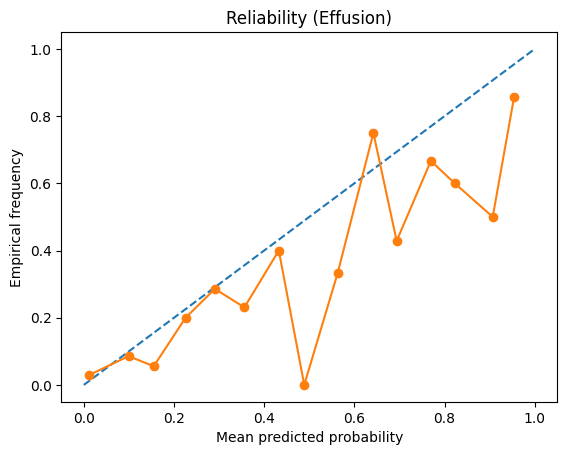

In [26]:
def expected_calibration_error(y_true, y_prob, n_bins=15):
    # y_true: (N,) in {0,1}; y_prob: (N,) in [0,1]
    bins = np.linspace(0.0, 1.0, n_bins+1)
    ece = 0.0
    for b0, b1 in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= b0) & (y_prob < b1)
        if mask.sum() == 0:
            continue
        conf = y_prob[mask].mean()
        acc  = y_true[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)
    return ece

def reliability_plot(y_true, y_prob, n_bins=15, title="Reliability diagram"):
    bins = np.linspace(0.0, 1.0, n_bins+1)
    bin_centers = []
    accs = []
    confs = []
    for b0, b1 in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= b0) & (y_prob < b1)
        if mask.sum() == 0:
            continue
        bin_centers.append((b0+b1)/2)
        confs.append(y_prob[mask].mean())
        accs.append(y_true[mask].mean())

    plt.figure()
    plt.plot([0,1],[0,1], linestyle="--")
    plt.plot(confs, accs, marker="o")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Empirical frequency")
    plt.title(title)
    plt.show()

# pick a class that has positives
calib_label = "Effusion" if "Effusion" in LABELS else LABELS[0]
i = LABELS.index(calib_label)
if np.unique(val_y[:, i]).size >= 2:
    ece = expected_calibration_error(val_y[:, i], val_probs[:, i], n_bins=15)
    print(f"ECE ({calib_label}):", ece)
    reliability_plot(val_y[:, i], val_probs[:, i], title=f"Reliability ({calib_label})")
else:
    print("Chosen class has no positives/negatives in val; pick another class.")

In [27]:
metrics_df.to_csv("nih_val_metrics.csv", index=False)
np.save("val_probs.npy", val_probs)
np.save("val_y.npy", val_y)
print("Saved: nih_val_metrics.csv, val_probs.npy, val_y.npy")

Saved: nih_val_metrics.csv, val_probs.npy, val_y.npy


In [28]:
!pip -q install timm

import timm
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vit_model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=len(LABELS)   # multi-label logits output
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(vit_model.parameters(), lr=5e-5, weight_decay=0.01)
scaler = torch.amp.GradScaler("cuda")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [29]:
EPOCHS = 5
for epoch in range(EPOCHS):
    vit_model.train()
    running, steps = 0.0, 0

    pbar = tqdm(train_loader, desc=f"ViT Epoch {epoch+1}/{EPOCHS}")
    for xb, yb in pbar:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda"):
            logits = vit_model(xb)
            loss = criterion(logits, yb)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running += loss.item()
        steps += 1
        pbar.set_postfix(loss=running/steps)

    print(f"ViT Epoch {epoch+1} avg train loss: {running/steps:.4f}")

ViT Epoch 1/5: 100%|██████████| 282/282 [02:38<00:00,  1.78it/s, loss=0.203]


ViT Epoch 1 avg train loss: 0.2027


ViT Epoch 2/5: 100%|██████████| 282/282 [02:37<00:00,  1.80it/s, loss=0.189]


ViT Epoch 2 avg train loss: 0.1893


ViT Epoch 3/5: 100%|██████████| 282/282 [02:21<00:00,  1.99it/s, loss=0.177]


ViT Epoch 3 avg train loss: 0.1773


ViT Epoch 4/5: 100%|██████████| 282/282 [02:22<00:00,  1.98it/s, loss=0.161]


ViT Epoch 4 avg train loss: 0.1614


ViT Epoch 5/5: 100%|██████████| 282/282 [02:22<00:00,  1.99it/s, loss=0.132]

ViT Epoch 5 avg train loss: 0.1319


In [31]:
# Save DenseNet final weights
torch.save(model.state_dict(), "densenet_final.pth")

# Save ViT final weights (if trained)
torch.save(vit_model.state_dict(), "vit_final.pth")

print("Final weights saved.")

Final weights saved.


In [32]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scaler_state_dict": scaler.state_dict(),
    "labels": LABELS,
}

torch.save(checkpoint, "densenet_checkpoint.pth")
print("Full checkpoint saved.")

Full checkpoint saved.


In [33]:
vit_checkpoint = {
    "model_state_dict": vit_model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scaler_state_dict": scaler.state_dict(),
    "labels": LABELS,
}

torch.save(vit_checkpoint, "vit_checkpoint.pth")
print("ViT checkpoint saved.")

ViT checkpoint saved.


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

def safe_auc(y_true, y_score):
    if np.unique(y_true).size < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)

def safe_ap(y_true, y_score):
    if np.unique(y_true).size < 2:
        return np.nan
    return average_precision_score(y_true, y_score)

def plot_roc_curves(y_true, y_prob, labels, show_top_k=5):
    # pick top-K classes by AUC
    aucs = [(lab, safe_auc(y_true[:, i], y_prob[:, i]))
            for i, lab in enumerate(labels)]
    aucs = sorted(aucs, key=lambda x: (x[1] if not np.isnan(x[1]) else -1), reverse=True)
    selected = [x[0] for x in aucs[:show_top_k]]

    plt.figure(figsize=(6,6))
    for lab in selected:
        i = labels.index(lab)
        if np.unique(y_true[:, i]).size < 2:
            continue
        fpr, tpr, _ = roc_curve(y_true[:, i], y_prob[:, i])
        auc_i = roc_auc_score(y_true[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f"{lab} (AUC={auc_i:.3f})")

    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Top ROC Curves")
    plt.legend()
    plt.show()

def plot_pr_curves(y_true, y_prob, labels, show_top_k=5):
    aps = [(lab, safe_ap(y_true[:, i], y_prob[:, i]))
           for i, lab in enumerate(labels)]
    aps = sorted(aps, key=lambda x: (x[1] if not np.isnan(x[1]) else -1), reverse=True)
    selected = [x[0] for x in aps[:show_top_k]]

    plt.figure(figsize=(6,6))
    for lab in selected:
        i = labels.index(lab)
        if np.unique(y_true[:, i]).size < 2:
            continue
        prec, rec, _ = precision_recall_curve(y_true[:, i], y_prob[:, i])
        ap_i = average_precision_score(y_true[:, i], y_prob[:, i])
        plt.plot(rec, prec, label=f"{lab} (AP={ap_i:.3f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Top PR Curves")
    plt.legend()
    plt.show()

             label  ROC_AUC   PR_AUC
             Edema 0.892205 0.315679
          Effusion 0.847922 0.414853
      Pneumothorax 0.846639 0.290987
     Consolidation 0.796477 0.154723
      Cardiomegaly 0.768267 0.326017
         Emphysema 0.763853 0.281700
            Hernia 0.752727 0.066951
              Mass 0.711648 0.150744
        No Finding 0.687847 0.695622
       Atelectasis 0.685501 0.175736
          Fibrosis 0.666719 0.157028
      Infiltration 0.617265 0.336275
         Pneumonia 0.549898 0.036241
            Nodule 0.467151 0.043174
Pleural_Thickening      NaN      NaN

ViT Summary:
Macro ROC-AUC: 0.7181513915188538
Micro ROC-AUC: 0.8608270479906731
Macro PR-AUC : 0.24612363421267686
Micro PR-AUC : 0.4784628050450145


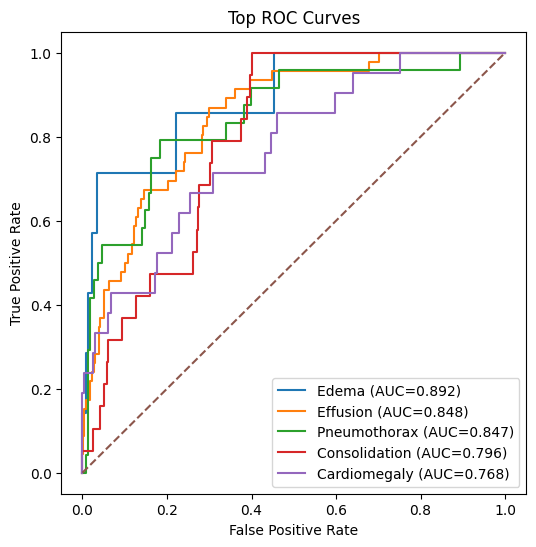

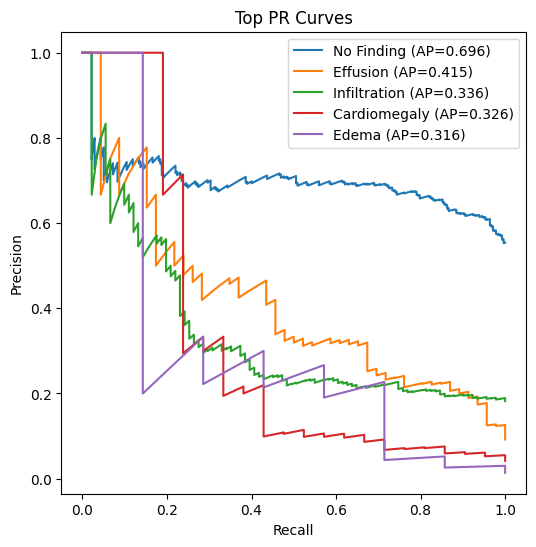

In [36]:
vit_val_probs, vit_val_logits, vit_val_y = collect_preds(vit_model, val_loader, device)

# Per-class AUC / AP
per_class_vit = []
for i, lab in enumerate(LABELS):
    auc_i = safe_auc(vit_val_y[:, i], vit_val_probs[:, i])
    ap_i  = safe_ap(vit_val_y[:, i], vit_val_probs[:, i])
    per_class_vit.append((lab, auc_i, ap_i))

vit_metrics_df = pd.DataFrame(per_class_vit, columns=["label", "ROC_AUC", "PR_AUC"])
print(vit_metrics_df.sort_values("ROC_AUC", ascending=False).to_string(index=False))

print("\nViT Summary:")
print("Macro ROC-AUC:", np.nanmean(vit_metrics_df["ROC_AUC"].values))
print("Micro ROC-AUC:", safe_auc(vit_val_y.reshape(-1), vit_val_probs.reshape(-1)))
print("Macro PR-AUC :", np.nanmean(vit_metrics_df["PR_AUC"].values))
print("Micro PR-AUC :", safe_ap(vit_val_y.reshape(-1), vit_val_probs.reshape(-1)))

plot_roc_curves(vit_val_y, vit_val_probs, LABELS)
plot_pr_curves(vit_val_y, vit_val_probs, LABELS)

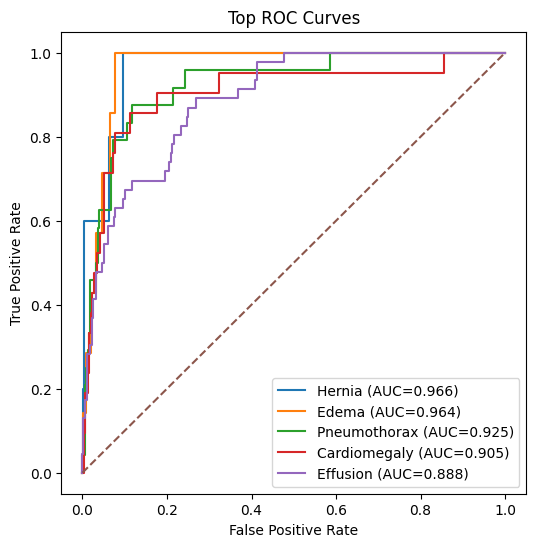

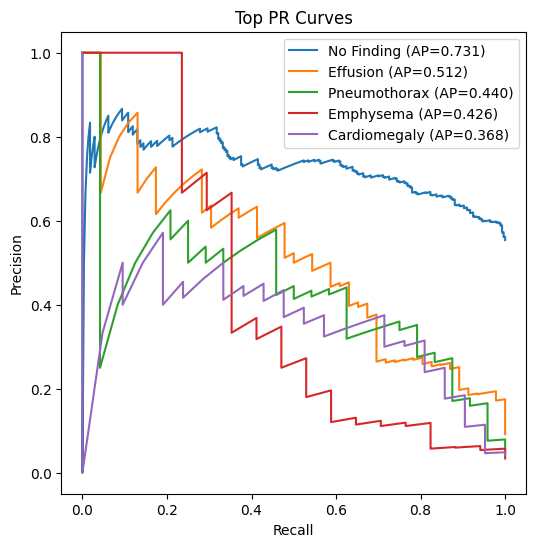

In [37]:
plot_roc_curves(val_y, val_probs, LABELS)
plot_pr_curves(val_y, val_probs, LABELS)